<a href="https://colab.research.google.com/github/EugOT/CN-pr-MDD-snRNA-seq/blob/main/notebooks/ClusteringOfPVInterNeurons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook uses only the female dataset and extracts parvalbumin-positive (PV) inhibitory interneurons based on expression of three canonical markers: PVALB, GAD1, and GAD2. It then performs gene selection, normalization, dimensionality reduction, clustering and differential gene expression.

Highly Variable Genes (HVGs) are genes that vary the most between cells, and therefore carry biological signal rather than noise.

Differentially Expressed Genes (DEGs) are genes that are significantly more or less expressed in one group of cells compared to others

[This notebook fully runs on my PC without changes with Python 3.10.0 but not with Python 3.13.0 -Liv]

In [1]:
# These packages are pre-installed on Google Colab, but are included here to facilitate running this notebook locally
!pip install --quiet matplotlib
!pip install --quiet scikit-learn
!pip install --quiet numpy
!pip install --quiet scipy
!pip install --quiet pacmap
!pip install --quiet leidenalg
!pip install --quiet sinfo
# snRNA-seq analysis
!pip install --quiet scanpy
!pip install --quiet omnipath
!pip install --quiet decoupler

You should consider upgrading via the 'C:\Users\Olivia\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'C:\Users\Olivia\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'C:\Users\Olivia\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'C:\Users\Olivia\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'C:\Users\Olivia\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'C:\Users\Olivia\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'C:\Users\Olivia\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade

In [2]:
!git clone https://github.com/EugOT/CN-pr-MDD-snRNA-seq.git
%cd /content/CN-pr-MDD-snRNA-seq/

[WinError 3] Das System kann den angegebenen Pfad nicht finden: '/content/CN-pr-MDD-snRNA-seq/'
c:\Users\Olivia\Downloads\MUW\WS25Neuroscience\CN-pr-MDD-snRNA-seq\notebooks_review_liv


Der Befehl "git" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.
C:\Users\Olivia\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [3]:
import os
import random
import pacmap
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import decoupler as dc

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from anndata.experimental.multi_files import AnnCollection


matplotlib.rcParams["pdf.use14corefonts"] = True
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica"]
matplotlib.rcParams["figure.max_open_warning"] = 20000


#Setting the same random seed means repeated runs give the same result for reproducability
reseed = 42
random.seed(reseed)
np.random.seed(reseed)

sc.settings.verbosity = 0  # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.settings.figdir = PLOTS_DIR
sc.settings.set_figure_params(
    dpi=180, dpi_save=600, vector_friendly=True, format="pdf", transparent=True
)
sc.settings.autoshow = True
sc.settings.autosave = False

In [4]:
#Load data
samples_females = pd.read_csv("data/PRJNA883411.tsv", delimiter="\t")
samples_females = samples_females[["Run", "Condition", "LibraryName", "BioProject", "Sex", "NTotalCells"]]

In [5]:
#Set filter parameters
#determine how many genes are kept / excluded
filtering_parameters = {
    "hvg_top_genes":6000, #orig: 5000       # number of Highly Variable Genes (HVGs)
    "pearson_residuals_top_genes":3000, # orig: 2000    # genes used after statistical variance normalization
    "min_cells_per_gene":5, #orig: 10       # remove genes expressed in <5 cells 
    "min_genes_per_cell":200, #orig: 500    # remove cells expressing <200 genes
}


#Load the female snRNA-seq dataset stored in AnnData format (standard format forScanpy,
#stores a gene matrix & metadata)
females = sc.read_h5ad(
    "data/PRJNA883411-whole_dataset-fpr_0.001-clusters.h5ad"
)
females.obs['Run'] = females.obs['orig.ident']
females.obs = pd.merge(females.obs, samples_females, on="Run", how = "inner").set_index("cell_name", drop=False)
females.uns["name"] = "PRJNA883411"

#Basic filtering by removing cells expressing too few genes (dead/low-quality)
# and genes expressed in too few cells (noise)
sc.pp.filter_cells(females, min_genes=filtering_parameters["min_genes_per_cell"])
sc.pp.filter_genes(females, min_cells=filtering_parameters["min_cells_per_gene"])

#Remove not needed metadata
females.obs = females.obs[[
    'cell_name',
    'background_fraction',
    'droplet_efficiency',
    'doublet_score',
    'nFeature_Diff',
    'nCount_Diff',
    'percent_mito',
    'percent_ribo',
    'percent_mito_ribo',
    'percent_hb',
    'log10GenesPerUMI',
    'k_tree',
    'Run',
    'Condition',
    'BioProject',
    'Sex',
    'n_genes']]

In [6]:
#Filter neurons based on the three gene markers for PV Interneurons
#Do this using a mask: PVALB > 0 AND GAD1 > 0 AND GAD2 > 0

pvalb_gene_index = females.var_names.get_loc('PVALB')
gad1_gene_index = females.var_names.get_loc('GAD1')
gad2_gene_index = females.var_names.get_loc('GAD2')
pv_neurons_mask = (females.X[:, pvalb_gene_index].toarray() > 0) & (females.X[:, gad1_gene_index].toarray() > 0) & (females.X[:, gad2_gene_index].toarray() > 0)
only_pv_neurons = females[pv_neurons_mask]
only_pv_neurons


View of AnnData object with n_obs × n_vars = 306 × 30266
    obs: 'cell_name', 'background_fraction', 'droplet_efficiency', 'doublet_score', 'nFeature_Diff', 'nCount_Diff', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_hb', 'log10GenesPerUMI', 'k_tree', 'Run', 'Condition', 'BioProject', 'Sex', 'n_genes'
    var: 'name', 'n_cells'
    uns: 'name'
    obsm: 'X_pacmap', 'X_pca', 'X_umap'

In [7]:
#Count PV cells per condition (Control vs MDD)
#in original 0 as control and MDD as 1

only_pv_neurons.obs.groupby(['Condition'])['cell_name'].count().reset_index()

#Replace numeric codes with text labels for clarity
pv_counts = only_pv_neurons.obs.groupby(['Condition'])['cell_name'].count().reset_index()
pv_counts['Condition'] = pv_counts['Condition'].map({0: 'Control', 1: 'MDD'})

pv_counts



,Condition,cell_name
0,Control,103
1,MDD,203


In [8]:
#Selects the 6000 (=n_top_genes) most informative genes.

#identify HVGs and then only keep them
adata = only_pv_neurons.copy()
sc.experimental.pp.highly_variable_genes(adata, flavor="pearson_residuals", n_top_genes=filtering_parameters["hvg_top_genes"])
adata = adata[:, adata.var["highly_variable"]]
#combine with k clustering info
adata.obs["k_tree"] = adata.obs["Sex"].astype(str) + "_" + adata.obs["k_tree"].astype(str)


C:\Users\Olivia\AppData\Local\Temp\ipykernel_4092\3407883778.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["k_tree"] = adata.obs["Sex"].astype(str) + "_" + adata.obs["k_tree"].astype(str)


In [9]:
#keep raw and depth-normalized counts for later
adata.layers["raw"] = adata.X.copy()
#Normalization by adjusting each cell so all have equal transcript counts
#Take square root to stabilize variance
adata.layers["sqrt_norm"] = np.sqrt(sc.pp.normalize_total(adata, inplace=False)["X"])
adata.raw = adata

#Pearson Residuals Normalization (removes technical effects like sequencing depth)
sc.experimental.pp.recipe_pearson_residuals(adata, n_top_genes=filtering_parameters["pearson_residuals_top_genes"], batch_key="Run")

In [10]:
hvgs = adata.var["highly_variable"]

#Dimensionality reduction with PaCMAP (Pairwise Controlled Manifold Approximation) 
#https://github.com/YingfanWang/PaCMAP
#compresses gene dimensions into 2D for visualization
embedding = pacmap.PaCMAP(
    n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, apply_pca=False
)

#store 2D coordinates
adata.obsm["X_pacmap"] = embedding.fit_transform(adata.obsm["X_pca"], init="pca")
n_cells = len(adata) #total number of cells

#Neighborhood graph for the cells based on top 50 PCA dimensions
#for UMAP visualization and clustering
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=50, method='umap')

#UMAP (Uniform Manifold Approximation and Projection) = another dimensionality reduction
#for visual interpretability
sc.tl.umap(adata, method='umap')

#Clustering with Leiden algorithm
#Identify cell groups with similar gene expression and assign numbers to these clusters
sc.tl.leiden(adata)

2025-12-09 04:42:22 | [WARNING] Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!
c:\Users\Olivia\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Olivia\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\Olivia\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\Olivia\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 966, in __init__
    se

In [11]:
#Trying to find DEGs for either condition (= want DEGs between MDD and control to see differences)

adata.obs['ConditionCategory'] = adata.obs['Condition'].astype('category')

#Rank genes between Control vs MDD with a t-test
sc.tl.rank_genes_groups(
    adata,
    groupby="ConditionCategory",  # Column defining your groups
    method="t-test",      # You can also try 'logreg', 'wilcoxon', or 't-test_overestim_var'
    key_added="degs_condition"
)

... storing 'k_tree' as categorical
... storing 'Run' as categorical
... storing 'BioProject' as categorical
... storing 'Sex' as categorical


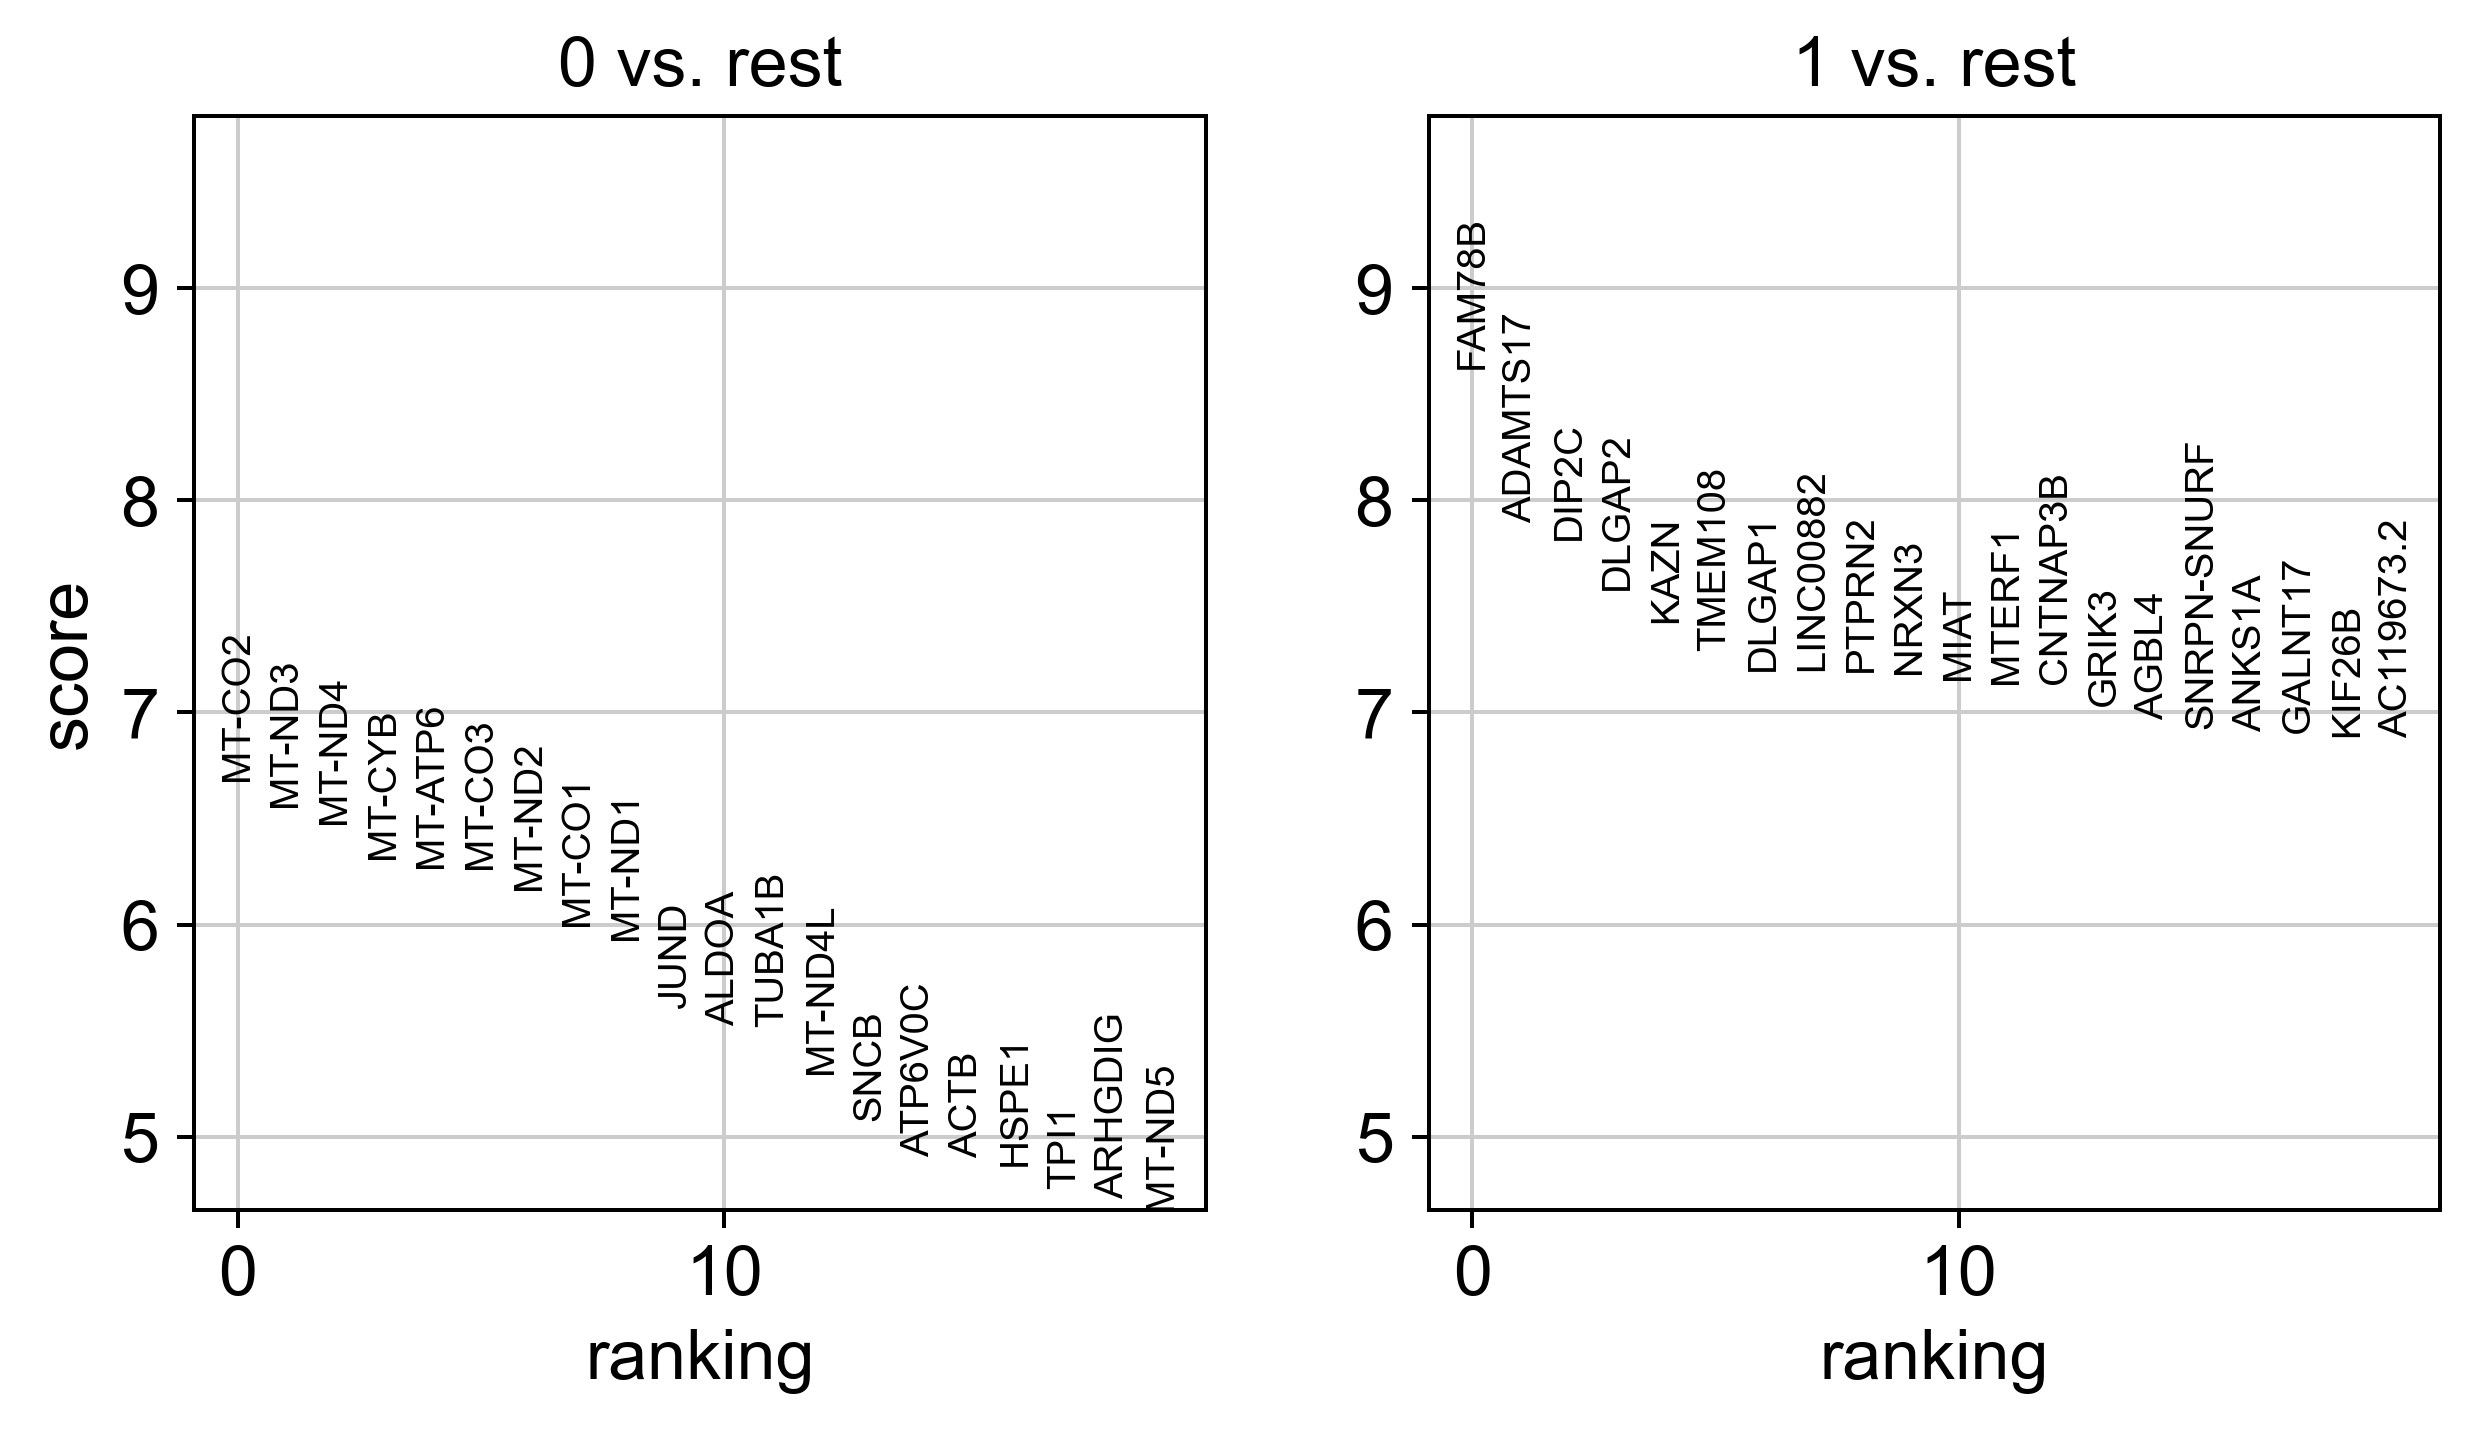

In [12]:
# Plot the top DEGs per condition

#1) "0 vs rest": compares Control cells (0) against all other cells
#2) "1 vs rest": compares MDD cells (1) against all other cells
#X-axis: gene rank (how strongly they are differentially expressed)
#Y-axis: test statistic value (higher = stronger differential expression for that gene in that group)
#Eg. mt-co2 is the most strongly enriched gene in Control cells

sc.pl.rank_genes_groups(adata, key='degs_condition')

In [13]:
#Rank genes for each Leiden cluster instead of condition
#Identify top genes as potential cluster markers
#(here no correspondence of 0 to control or 1 to MDD)
sc.tl.rank_genes_groups(adata, 'leiden', method='logreg', key_added="leiden")

c:\Users\Olivia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


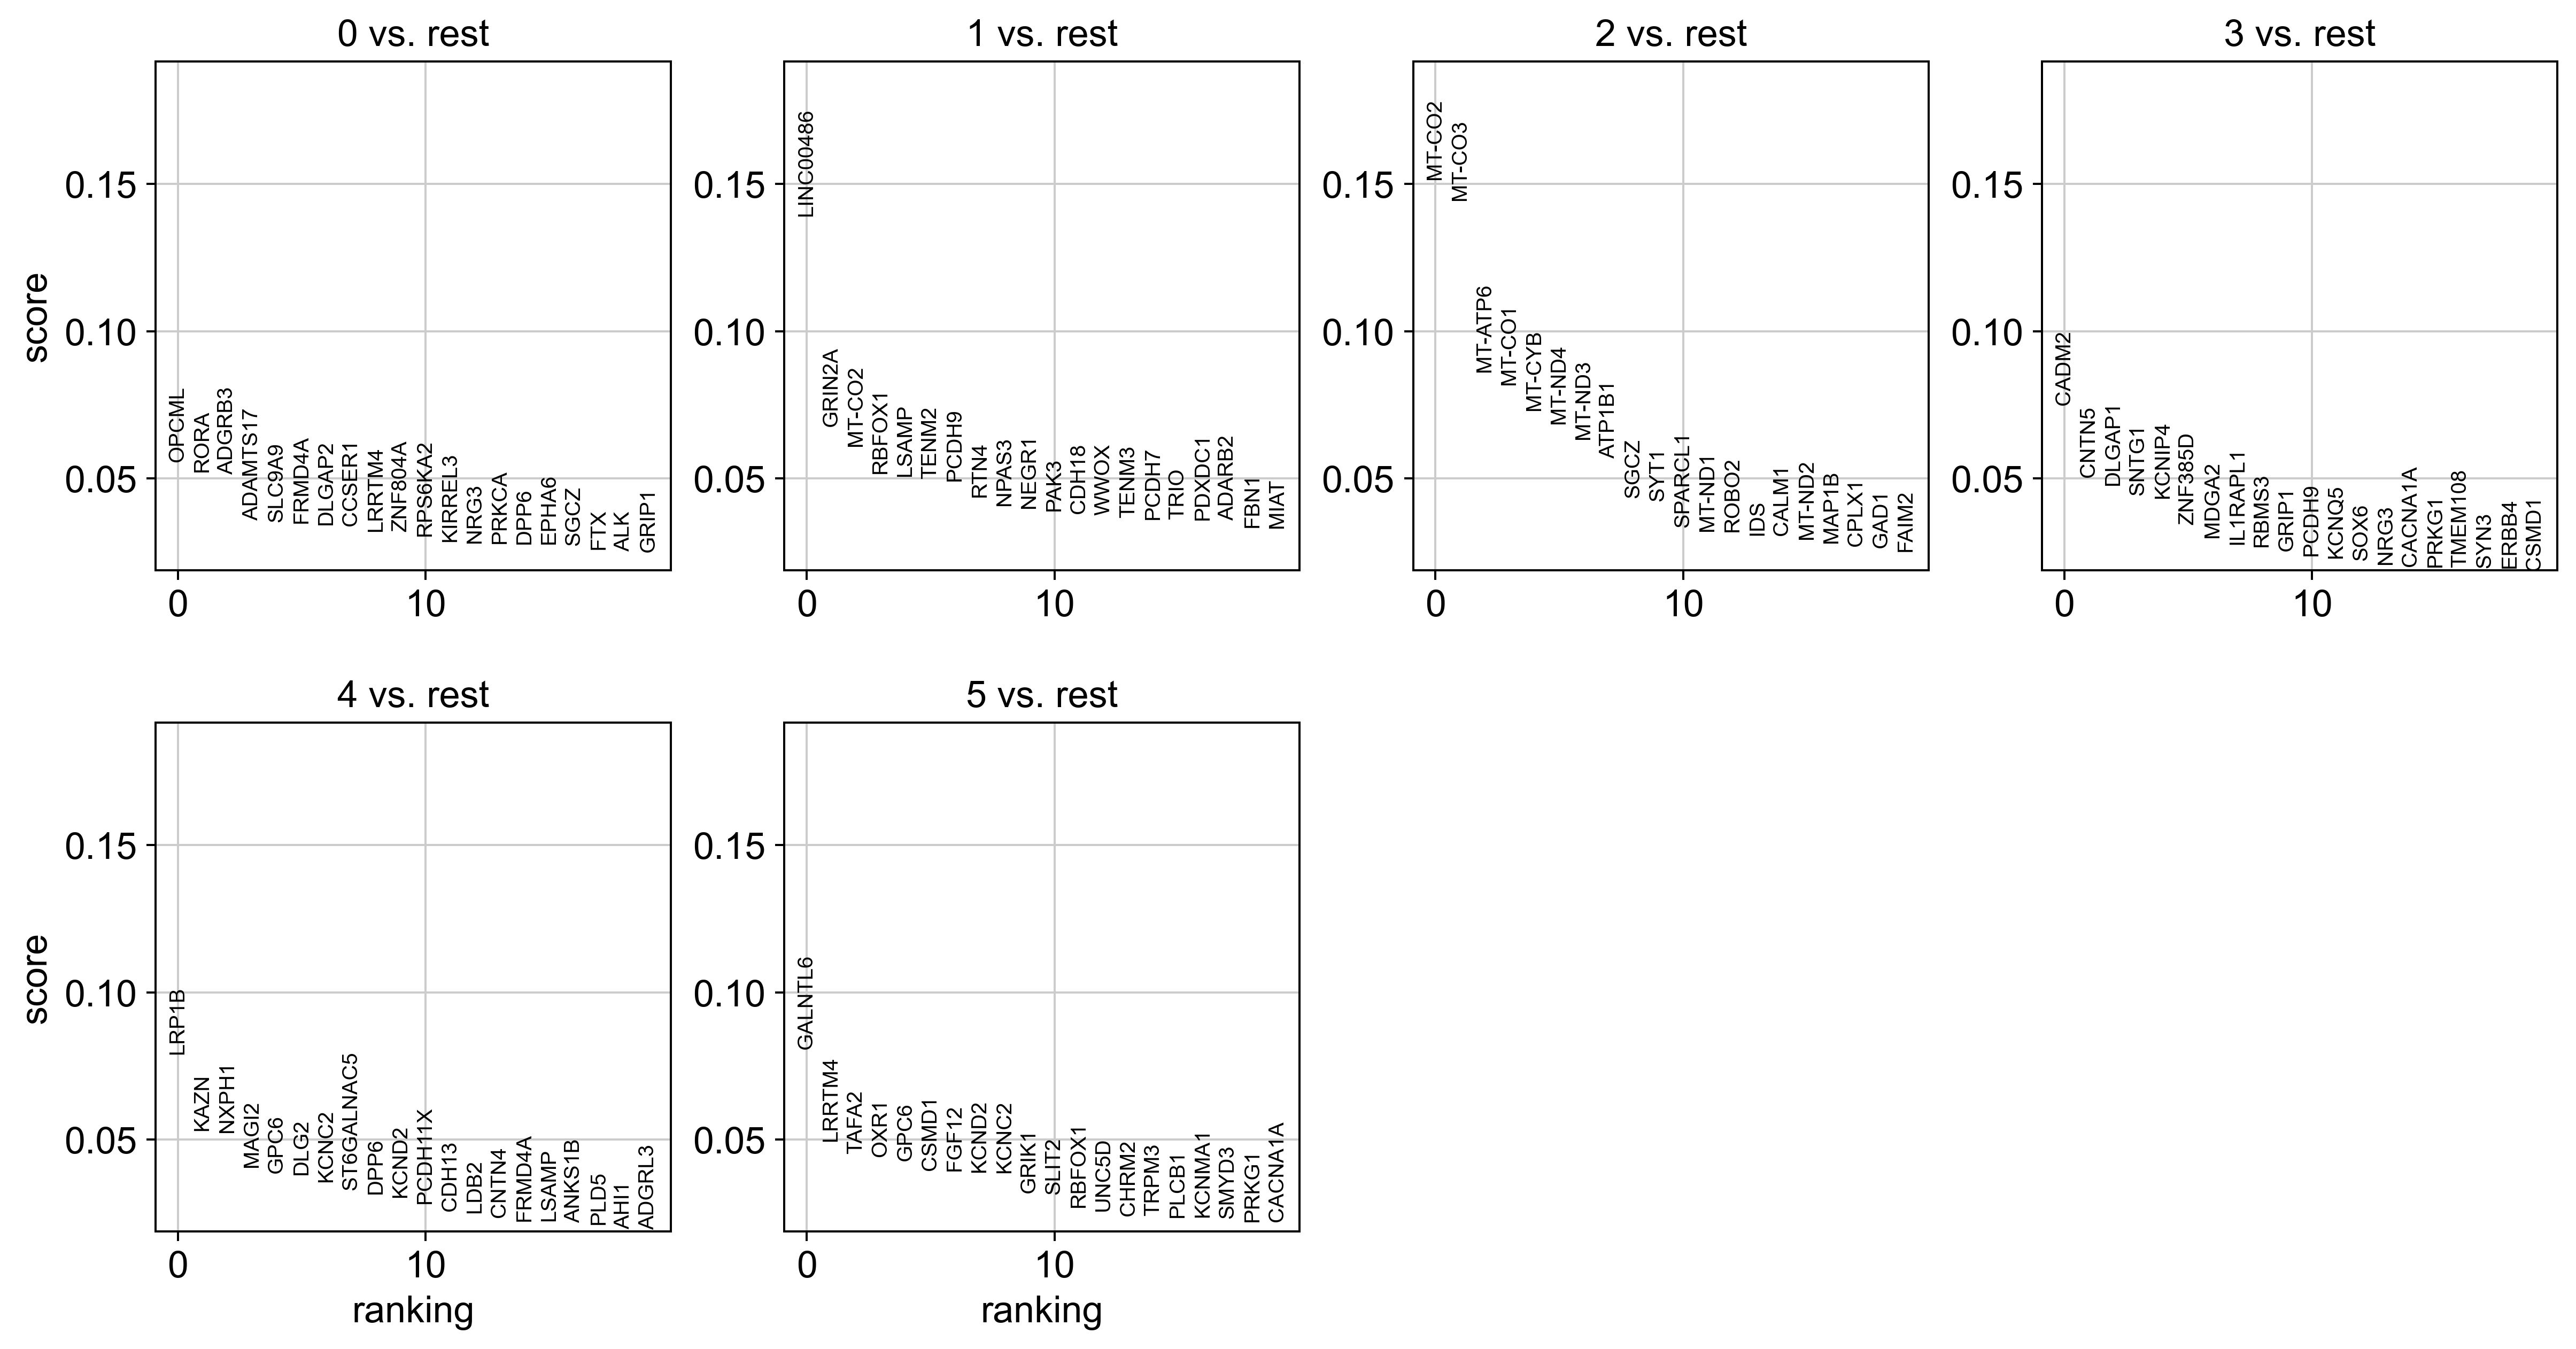

In [14]:
sc.pl.rank_genes_groups(adata, key='leiden')

In [15]:
adata

AnnData object with n_obs × n_vars = 306 × 6000
    obs: 'cell_name', 'background_fraction', 'droplet_efficiency', 'doublet_score', 'nFeature_Diff', 'nCount_Diff', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'percent_hb', 'log10GenesPerUMI', 'k_tree', 'Run', 'Condition', 'BioProject', 'Sex', 'n_genes', 'leiden', 'ConditionCategory'
    var: 'name', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'name', 'hvg', 'pca', 'pearson_residuals_normalization', 'neighbors', 'umap', 'leiden', 'degs_condition'
    obsm: 'X_pacmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'sqrt_norm'
    obsp: 'distances', 'connectivities'

In [16]:
#Count how many cells are in each cluster (Leiden) per condition (Control as 0 vs MDD as 1)
adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()

#Replace numeric codes with text labels for clarity
leiden_cluster = adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()
leiden_cluster['Condition'] = leiden_cluster['Condition'].map({0: 'Control', 1: 'MDD'})

leiden_cluster

#Eg. cluster 0 has 11 Control cells and 80 MDD cells (--> 0 mostly contains MDD cells)

C:\Users\Olivia\AppData\Local\Temp\ipykernel_4092\2579903787.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()
C:\Users\Olivia\AppData\Local\Temp\ipykernel_4092\2579903787.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leiden_cluster = adata.obs.groupby(["leiden","Condition"])["cell_name"].count().reset_index()


,leiden,Condition,cell_name
0,0,Control,11
1,0,MDD,80
2,1,Control,37
3,1,MDD,34
4,2,Control,43
5,2,MDD,13
6,3,Control,6
7,3,MDD,36
8,4,Control,5
9,4,MDD,22
